In [78]:
import matplotlib.pyplot as plt
from collections import Counter

N = 5000
m = 4

# Initialize Library
Network = {node: [] for node in range(N)}



Connect Nodes in Nucleus

In [79]:


# Initial nucleus size
n0 = m + 1

# Connect every node in the nucleus to each other
for node1 in range(n0):
        for node2 in range(node1 + 1 , n0):  # More efficient than adding (if node1 != node2) loop
            Network[node1].append(node2)
            Network[node2].append(node1)

# Debug 
print(Network)

{0: [1, 2, 3, 4], 1: [0, 2, 3, 4], 2: [0, 1, 3, 4], 3: [0, 1, 2, 4], 4: [0, 1, 2, 3], 5: [], 6: [], 7: [], 8: [], 9: [], 10: [], 11: [], 12: [], 13: [], 14: [], 15: [], 16: [], 17: [], 18: [], 19: [], 20: [], 21: [], 22: [], 23: [], 24: [], 25: [], 26: [], 27: [], 28: [], 29: [], 30: [], 31: [], 32: [], 33: [], 34: [], 35: [], 36: [], 37: [], 38: [], 39: [], 40: [], 41: [], 42: [], 43: [], 44: [], 45: [], 46: [], 47: [], 48: [], 49: [], 50: [], 51: [], 52: [], 53: [], 54: [], 55: [], 56: [], 57: [], 58: [], 59: [], 60: [], 61: [], 62: [], 63: [], 64: [], 65: [], 66: [], 67: [], 68: [], 69: [], 70: [], 71: [], 72: [], 73: [], 74: [], 75: [], 76: [], 77: [], 78: [], 79: [], 80: [], 81: [], 82: [], 83: [], 84: [], 85: [], 86: [], 87: [], 88: [], 89: [], 90: [], 91: [], 92: [], 93: [], 94: [], 95: [], 96: [], 97: [], 98: [], 99: [], 100: [], 101: [], 102: [], 103: [], 104: [], 105: [], 106: [], 107: [], 108: [], 109: [], 110: [], 111: [], 112: [], 113: [], 114: [], 115: [], 116: [], 117: [

Auxilary List

In [80]:
# Initialize Aux. list
aux_list = []

# Initialize initial nucleus nodes
for node in range(n0):
    for i in range(len(Network[node])):
        aux_list.append(node)

print(aux_list)

[0, 0, 0, 0, 1, 1, 1, 1, 2, 2, 2, 2, 3, 3, 3, 3, 4, 4, 4, 4]


Create New Nodes

In [81]:
# Add new nodes from n0 to N
for new_node in range(n0, N):

    connected_nodes = []
    while len(connected_nodes) < m:
        # Randomly select attachment node
        the_chosen_node = random.choice(aux_list)
        if the_chosen_node not in connected_nodes:
            connected_nodes.append(the_chosen_node)

            # Append 'the_chosen_node' at the index 'new_node' in Network
            # Connect the two using the same method as the initial nucleus
            Network[new_node].append(the_chosen_node)
            Network[the_chosen_node].append(new_node)

    # Update auxiliary list
    aux_list.extend([new_node] * m)  # Add the new node j, m times
    for node in connected_nodes:
        aux_list.append(node)  # Add each connected node once


print(Network)




{0: [1, 2, 3, 4, 5, 6, 9, 10, 11, 12, 13, 18, 22, 27, 29, 35, 36, 44, 48, 50, 53, 58, 60, 68, 74, 80, 82, 84, 93, 108, 109, 111, 112, 117, 119, 134, 142, 143, 144, 153, 156, 171, 173, 183, 185, 216, 219, 222, 238, 243, 248, 266, 270, 272, 286, 332, 340, 358, 364, 372, 377, 380, 391, 397, 401, 434, 438, 463, 472, 496, 532, 542, 549, 577, 578, 601, 614, 616, 732, 747, 748, 772, 828, 841, 862, 950, 977, 1003, 1014, 1023, 1025, 1074, 1084, 1093, 1110, 1120, 1134, 1152, 1153, 1193, 1200, 1205, 1211, 1254, 1258, 1273, 1300, 1317, 1321, 1329, 1345, 1378, 1399, 1418, 1431, 1443, 1492, 1512, 1539, 1546, 1554, 1556, 1572, 1605, 1634, 1644, 1653, 1668, 1703, 1737, 1774, 1855, 1866, 1929, 1936, 1939, 1942, 1959, 1969, 1972, 2004, 2057, 2097, 2113, 2115, 2132, 2212, 2215, 2236, 2263, 2287, 2320, 2322, 2358, 2365, 2411, 2413, 2448, 2495, 2650, 2738, 2809, 2868, 2927, 2962, 2993, 2996, 3000, 3013, 3032, 3115, 3146, 3161, 3181, 3296, 3308, 3362, 3391, 3427, 3429, 3506, 3569, 3593, 3617, 3664, 3701, 38

In [82]:

k_list = []
mf_approx_list = []
for node in Network:
    k = len(Network[node])
    k_list.append(k)

    mf_approx = (2*(m^2)) / (k^3)
    mf_approx_list.append(mf_approx)



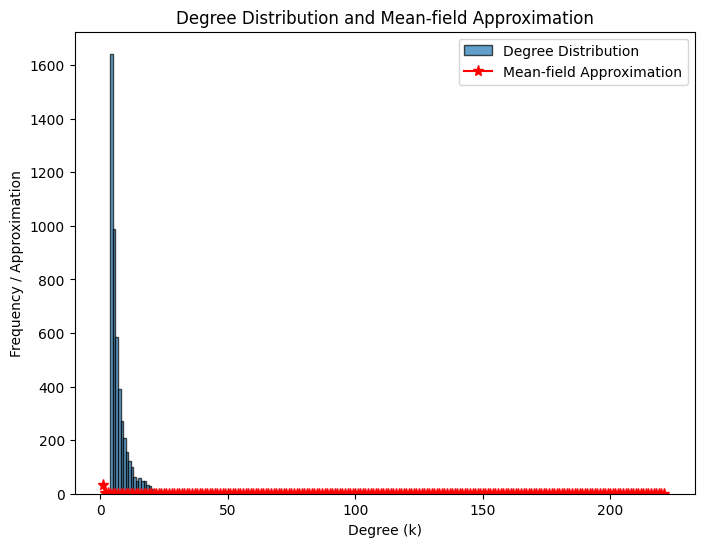

In [85]:

# Calculate degree list (k_list)
k_list = [len(Network[node]) for node in Network]

# Step 1: Plot the degree distribution as a histogram
plt.figure(figsize=(8, 6))

# Histogram of degree distribution
plt.hist(k_list, bins=range(min(k_list), max(k_list) + 2), edgecolor='black', alpha=0.7, label='Degree Distribution')

# Step 2: Generate the degree values for the mean-field approximation
degree_axis = list(range(1, max(k_list) + 1))  # Range from 1 to max degree in the network
mf_approx_list = [(2 * (m ** 2)) / (k**3) for k in degree_axis]  # Mean-field approximation

# Plot the mean-field approximation
plt.plot(degree_axis, mf_approx_list, 'r*-', label="Mean-field Approximation", markersize=8)

# Labels and title
plt.xlabel('Degree (k)')
plt.ylabel('Frequency / Approximation')
plt.title('Degree Distribution and Mean-field Approximation')

# Add a legend
plt.legend()

# Show the plot
plt.show()
